# ERP analysis using MNE

> A serious attempt at all the assignments is mandatory to grant access to the final exam. Refer to the course manual for more details (section *Overview* on Brightspace). 

> Please add today's topic to your knowledge graph.

**Learning goals:**
- Get familiar with the MNE toolbox for EEG analysis;
- Get familiar with sklearn for EEG decoding;
- Understand ERPs and their sptial and temporal components; 
- Understand temporal, spatial, and spatio-temporal decoding;
- Understand significance testing using the permutation test.

**Solutions file:**

For this assignment, a solutions file will be released after the deadline.


## Top-down view onto this notebook
This notebook is designed to perform the basics of ERP analysis and classification in order to get familiar with commonly used toolboxes, like mne and sklearn. You will do so using real EEG data, unlike the toy datasets that you have seen before. This notebook goes through several of the basic steps that are involved in an ERP-pipeline, being reading the data, preprocessing of the data, feature extraction, classification using cross-validation, and evaluation including statistics. 
1. In exercise 1, you will download the dataset and setup your environment;
1. In exercise 2, you will load the dataset and preprocess it. You will be asked to extract a few characteristics of the dataset to get familiar with it and where things are stored in mne objects;
1. In exercise 3, you will visualize both the temporal as well as the spatial distributions of basic ERPs for each of the conditions in the dataset and inspect these;
1. In exercise 4, you will decode target versus non-target responses using LDA, and using spatial information only;
1. In exercise 5, you will decode target versus non-target responses using LDA, and using temporal information only;
1. In exercise 6, you will decode target versus non-target responses using LDA, and using spatio-temporal information;
1. In exercise 7, you will learn about permutation testing, which is a powerful tool to assess whether a specific test statistic (here classification accuracy) is significantly higher than chance. 


In [1]:
import pickle
import mne
import re
from pathlib import Path
import logging
from matplotlib import pyplot as plt
import seaborn as sns
import yaml
import os
import glob
import warnings
import numpy as np
import pandas as pd
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import cross_val_score
warnings.simplefilter(action='ignore', category=RuntimeWarning)

sns.set_style('whitegrid')
mne.set_log_level('WARNING')

np.random.seed(42)

## Exercise 1: Download and setup data
This notebook is designed to perform the basics of ERP analysis and classification in order to get familiar with commonly used toolboxes, like mne and sklearn.

The dataset contains data of three subjects. For each subject, data of a single session is available. Within a session, a resting state recording with eyes open and eyes closed has been performed at the beginning and the end, which you can ignore. In the main part of the session, an auditory oddball paradigm was executed. For two different stimulus onset asynchrony (SOA) values, a fast and a slow condition, 80 trials of oddball ERP data were collected. Within a trial, you should find 90 stimuli (75 low-pitched non-targets and 15 high-pitched targets). Please note, that the actual SOA values vary between subjects.

In addition to EEG channels, a number of other non-EEG channels have been recorded.

1. Retrieve the data from [Zenodo](https://zenodo.org/record/4066633) and store it at a convenient location locally;
1. In the code snippet below, set the `CONFIG_FILE_PATH` to point the folder where the `config.yaml` file is located;
1. Open the `config.yaml` file in a text editor, and change the `data_path` to point to the path where you downloaded the data.

In [2]:
# Adjust this CONFIG_FILE_PATH to point to the config.yaml file
CONFIG_FILE_PATH = os.path.join(os.getcwd(), 'data', 'config.yaml')  # The return value is the concatenation of path and all members of *paths

# Load the file
conf = yaml.load(open(CONFIG_FILE_PATH, 'r'), Loader=yaml.FullLoader)


In [3]:
# Load one data example
# raw = mne.io.read_raw_brainvision("/data/eeg_tutorial_erp_data/erp_subject_1/Oddball_Run_2_Trial_001_SOA_0.508_slow.vhdr", preload=True)
raw = mne.io.read_raw_brainvision("C:/Users/ptrso/Desktop/MasteRU/BCI/Assignments/Assignment6/data/eeg_tutorial_erp_data/erp_subject_1/Oddball_Run_2_Trial_001_SOA_0.508_slow.vhdr", preload=True)
eeg_data = raw.get_data()
info = raw.info

print("Shape of data:", eeg_data.shape)
print(info)
print('------')

events, event_ids = mne.events_from_annotations(raw)
print(event_ids)
print("Events example snippet:\n", events[0:5])

Shape of data: (37, 54780)
<Info | 7 non-empty values
 bads: []
 ch_names: Fp1, Fp2, F3, F4, C3, C4, P3, P4, O1, O2, F7, F8, T7, T8, P7, ...
 chs: 37 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 250.0 Hz
 meas_date: 1924-01-01 00:00:00 UTC
 nchan: 37
 projs: []
 sfreq: 1000.0 Hz
>
------
{'New Segment/': 99999, 'Stimulus/S  1': 1, 'Stimulus/S 21': 21, 'Stimulus/S255': 255}
Events example snippet:
 [[    0     0 99999]
 [ 5725     0    21]
 [ 6234     0     1]
 [ 6742     0     1]
 [ 7251     0     1]]


1. What is the channel count? Answer: 37 channels

1. What is the sampling rate? 1000.0 Hz

1. What are the names of events (also referred to as markers) present in this dataset? The dataset contains the following event markers:
'New Segment/', 'Stimulus/S 1', 'Stimulus/S 21', and 'Stimulus/S255'. Among these, 'Stimulus/S 1' and 'Stimulus/S 21' correspond to the experimental stimuli used in the oddball task fast and slow. Lastly, Stimulus/S255 indicates the end of the trial since there are 55 sec in the experiment S2(1-55) calculated by trials / sampling rate

## Exercise 2: Loading and processing ERP data

First we need to obtain the list of relevant EEG files. Then we load the raw data. It consists of three files per recording. Please explore them! **Hint**: look into a `eeg_data` variable and print its `info` attribute.
1. What is the channel count? Answers above
1. What is the sampling rate? 
1. What are the names of events (also referred to as markers) present in this dataset? 

In a next step, the channel layout that was used for the recording needs to be set.

The first preprocessing steps are performed on the continous data, while later preprocessing steps are performed on time windows of data (so called epochs), which are cut out from the continuous data relative to the onset of every stimulus.

Preprocessing steps:
- Bandpass filtering
- Selecting only EEG channels
- Epoching
- Baselining

Finally, we have concatenated all loaded files into one variable that contains all preprocessed EEG epochs for one subject/condition pair.

When you have understood this entire notebook, inspect changes in the preprocessing to the ERPs and decoding performance:
1. Perform the bandpass filtering after epoching instead of at the beginning of the pipeline. What do you observe, if you continue with the script using this wrong preprocessing order? Why do you think this is happening? How could you possibly save the day while still running the frequency filtering on epochs? **Hint:** it might be required to look at individual epochs instead of ERPs.
1. Try to see how using epoch rejection with min-max thresholds impacts performance. **Hint**: pay attention to Subject 1, slow condition and Subject 3, both conditions.


In [4]:
def get_file_list(data_path, session, condition): # looking inside subject folders for all .vhdr files with each condition
    sep = os.path.sep  # separation symbol
    search_path = f'{data_path}{sep}{session}{sep}*{condition}.vhdr'
    print(f'Loading files matching {search_path}')
    return sorted(glob.glob(search_path))

# decimate: Keeps 1 in every 10 samples (downsampling) 1000 Hz -> 100 Hz
# baseline_ival: Baseline corrects mean signal in pre-stimulus window (200 ms)
# cropping would completely remove it
def preprocessed_to_epoch(preprocessed_data, decimate=10, baseline_ival=(-.2, 0)):
    raw_stim_ids = {"Stimulus/S  1": 1, "Stimulus/S 21": 2}  # changes stimulus labels
    class_ids = {"Target": 2, "Non-target": 1}  # sets them as (non-)target instead
    reject = dict()
    # reject = dict(eeg=60 * 1e-6)
    events = mne.events_from_annotations(preprocessed_data, event_id=raw_stim_ids)[0]
    epo_data = mne.Epochs(preprocessed_data, events, event_id=class_ids,
                          baseline=baseline_ival, decim=decimate,
                          reject=reject, proj=False, preload=True)
    return epo_data

non_eeg_channels = ['EOGvu', 'x_EMGl', 'x_GSR', 'x_Respi', 'x_Pulse', 'x_Optic']
local_data_path = conf['data_path']
session_list = conf['auditory_oddball']['session_list']
condition_list = conf['auditory_oddball']['condition_list']

all_data = dict()
filter_band = (1.5, 16)
baseline_ival = None  # (-.2, 0)

for session in session_list:
    for condition in condition_list:
        
        # Find files
        eeg_filepaths = get_file_list(local_data_path, session, condition)
        
        # Read, preprocess, and slice the data
        epo_arr = []
        for eeg_filepath in eeg_filepaths:
            eeg_data = mne.io.read_raw_brainvision(eeg_filepath, misc=non_eeg_channels)
            eeg_data.set_montage('standard_1020').load_data()  # mapping for 10-20 electrodes
            eeg_data.filter(filter_band[0], filter_band[1], method='iir')  # infinite impulse response filter
            eeg_data.pick_types(eeg=True)
            epo_data = preprocessed_to_epoch(eeg_data, baseline_ival=baseline_ival)
            epo_arr.append(epo_data)
            
        # Add to data stack
        if session not in all_data:
            all_data[session] = dict()
        if condition not in all_data[session]:
            all_data[session][condition] = mne.concatenate_epochs(epo_arr) # one concatenated Epochs per condition per session
            
print("Done!")

Loading files matching C:\Users\ptrso\Desktop\MasteRU\BCI\Assignments\Assignment6\data\eeg_tutorial_erp_data\erp_subject_1\*fast.vhdr
Loading files matching C:\Users\ptrso\Desktop\MasteRU\BCI\Assignments\Assignment6\data\eeg_tutorial_erp_data\erp_subject_1\*slow.vhdr
Loading files matching C:\Users\ptrso\Desktop\MasteRU\BCI\Assignments\Assignment6\data\eeg_tutorial_erp_data\erp_subject_2\*fast.vhdr
Loading files matching C:\Users\ptrso\Desktop\MasteRU\BCI\Assignments\Assignment6\data\eeg_tutorial_erp_data\erp_subject_2\*slow.vhdr
Loading files matching C:\Users\ptrso\Desktop\MasteRU\BCI\Assignments\Assignment6\data\eeg_tutorial_erp_data\erp_subject_3\*fast.vhdr
Loading files matching C:\Users\ptrso\Desktop\MasteRU\BCI\Assignments\Assignment6\data\eeg_tutorial_erp_data\erp_subject_3\*slow.vhdr
Done!


Comparing filter before and after on: C:\Users\ptrso\Desktop\MasteRU\BCI\Assignments\Assignment6\data\eeg_tutorial_erp_data\erp_subject_3\Oddball_Run_2_Trial_065_SOA_0.513_slow.vhdr
Correct order:


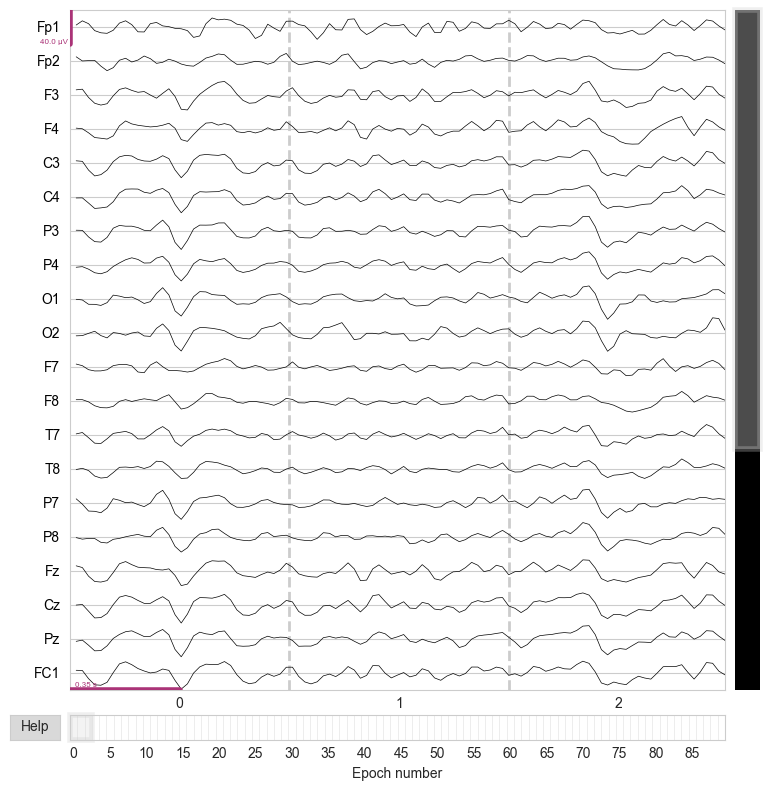

In [5]:
print("Comparing filter before and after on:", eeg_filepaths[-1])
test_file = eeg_filepaths[-1]  # LAST subject, codition and trial

eeg_unf_data = mne.io.read_raw_brainvision(test_file, misc= non_eeg_channels)
eeg_unf_data.set_montage('standard_1020').load_data()
# Filtering before preprocessing
eeg_f_data = eeg_unf_data.filter(l_freq = filter_band[0],h_freq = filter_band[1], method ='iir')
epo_f_data = preprocessed_to_epoch(eeg_f_data, baseline_ival=baseline_ival)


print("Correct order:")     
epo_f_data.plot(n_epochs=3, n_channels=20)
print()  

Wrong order:


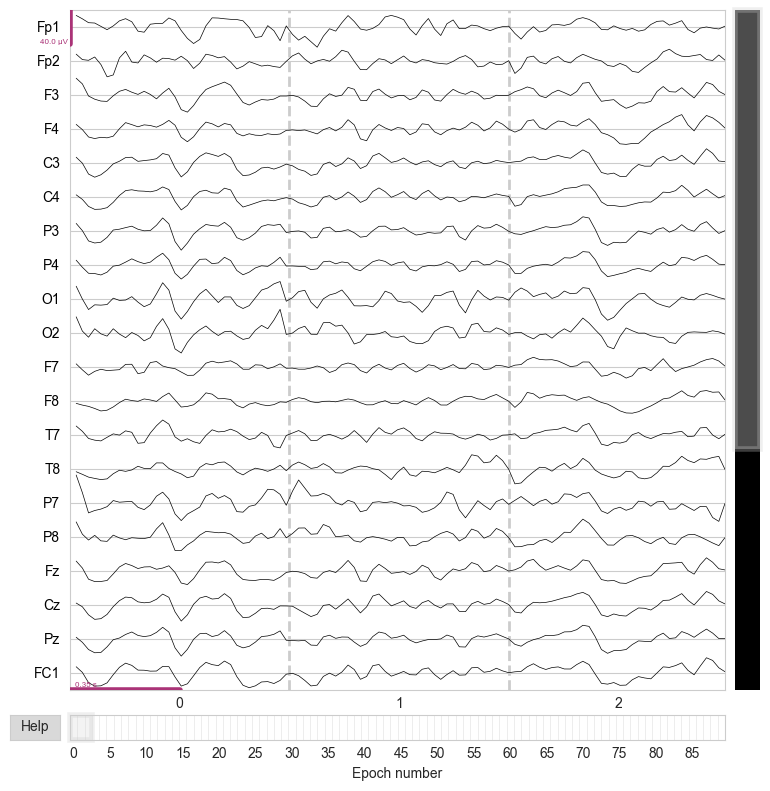

Figure(800x800)


In [6]:
eeg_unf_data = mne.io.read_raw_brainvision(test_file, misc= non_eeg_channels)
eeg_unf_data.set_montage('standard_1020').load_data()
# Filtering after preprocessing
epo_unf_data = preprocessed_to_epoch(eeg_unf_data, baseline_ival=baseline_ival)
epo_f_data = epo_unf_data.filter(l_freq = filter_band[0],h_freq = filter_band[1], method ='iir')

print("Wrong order:")
print(epo_f_data.plot(n_epochs=3, n_channels=20))      

#### 1) Answer
The edges of the epoch at the start and the end are jagged. There are some edge artifacts that distort the signals abnormally. This happens because the filter requires a lot of temporal information to properly filter the signals and when the data is not continuous it is hard to achieve. Moreover, the epochs are independent from each other and since they are being filtered by themselves the artifacts are different for each epoch as well. Additionally, we could also crop some timepoints close to the edges of the epochs as well.

If we must keep filtering after the epoch stage, the simplest way to reduce the edge "ringing" without additional steps, is to use filter padding. This gives the filter artificial context by reflecting the edges, reducing, but not eliminating the distortions.
```
epo_after.filter(filter_band[0], filter_band[1], method='iir', pad='reflect_limited')
```

In [7]:
def preprocessed_to_epoch(preprocessed_data, decimate=10, baseline_ival=(-.2, 0)):
    raw_stim_ids = {"Stimulus/S  1": 1, "Stimulus/S 21": 2}  # changes stimulus labels
    class_ids = {"Target": 2, "Non-target": 1}  # sets them as (non-)target instead
    # reject = dict()
    reject = dict(eeg=60 * 1e-6)
    events = mne.events_from_annotations(preprocessed_data, event_id=raw_stim_ids)[0]
    epo_data = mne.Epochs(preprocessed_data, events, event_id=class_ids,
                          baseline=baseline_ival, decim=decimate,
                          reject=reject, proj=False, preload=True)
    epo_clean = epo_data.copy()
    epo_clean.drop_bad(reject=reject)
    return epo_clean

non_eeg_channels = ['EOGvu', 'x_EMGl', 'x_GSR', 'x_Respi', 'x_Pulse', 'x_Optic']
local_data_path = conf['data_path']
session_list = conf['auditory_oddball']['session_list']
condition_list = conf['auditory_oddball']['condition_list']
condition_list_init = condition_list.copy()

new_data = dict()
filter_band = (1.5, 16)
baseline_ival = None  

session_list_new = [session_list[0], session_list[2]]
condition_slow = [condition_list[1]]
# print(session_list_new)
# print(condition_slow)

for session in session_list_new:

    if session == session_list_new[0]: condition_list = condition_slow
    else: condition_list = condition_list_init

    for condition in condition_list:
        
        # Find files
        eeg_filepaths = get_file_list(local_data_path, session, condition)
        
        # Read, preprocess, and slice the data
        epo_arr = []
        for eeg_filepath in eeg_filepaths:
            eeg_data = mne.io.read_raw_brainvision(eeg_filepath, misc=non_eeg_channels)
            eeg_data.set_montage('standard_1020').load_data()  # mapping for 10-20 electrodes
            eeg_data.filter(filter_band[0], filter_band[1], method='iir')  # infinite impulse response filter
            eeg_data.pick_types(eeg=True)
            epo_clean_data = preprocessed_to_epoch(eeg_data, baseline_ival=baseline_ival)
            epo_arr.append(epo_clean_data)
            
        # Add to data stack
        if session not in new_data:
            new_data[session] = dict()
        if condition not in new_data[session]:
            new_data[session][condition] = mne.concatenate_epochs(epo_arr) # one concatenated Epochs per condition per session
            
print("Done!")

Loading files matching C:\Users\ptrso\Desktop\MasteRU\BCI\Assignments\Assignment6\data\eeg_tutorial_erp_data\erp_subject_1\*slow.vhdr
Loading files matching C:\Users\ptrso\Desktop\MasteRU\BCI\Assignments\Assignment6\data\eeg_tutorial_erp_data\erp_subject_3\*fast.vhdr
Loading files matching C:\Users\ptrso\Desktop\MasteRU\BCI\Assignments\Assignment6\data\eeg_tutorial_erp_data\erp_subject_3\*slow.vhdr
Done!


Subject 1 slow: kept 1005 / 1800
Subject 3 slow: kept 1650 / 1800
Subject 3 fast: kept 1691 / 1800


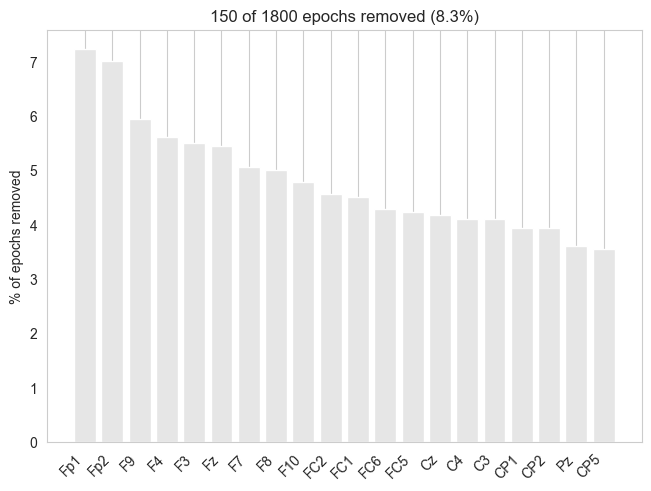

In [8]:
print(f"Subject 1 slow: kept {len(new_data['erp_subject_1']['slow'])} / {len(all_data['erp_subject_1']['slow'])}")
print(f"Subject 3 slow: kept {len(new_data['erp_subject_3']['slow'])} / {len(all_data['erp_subject_3']['slow'])}")
print(f"Subject 3 fast: kept {len(new_data['erp_subject_3']['fast'])} / {len(all_data['erp_subject_3']['fast'])}")

new_data['erp_subject_3']['slow'].plot_drop_log()
all_data['erp_subject_3']['slow'].plot_drop_log()
print()


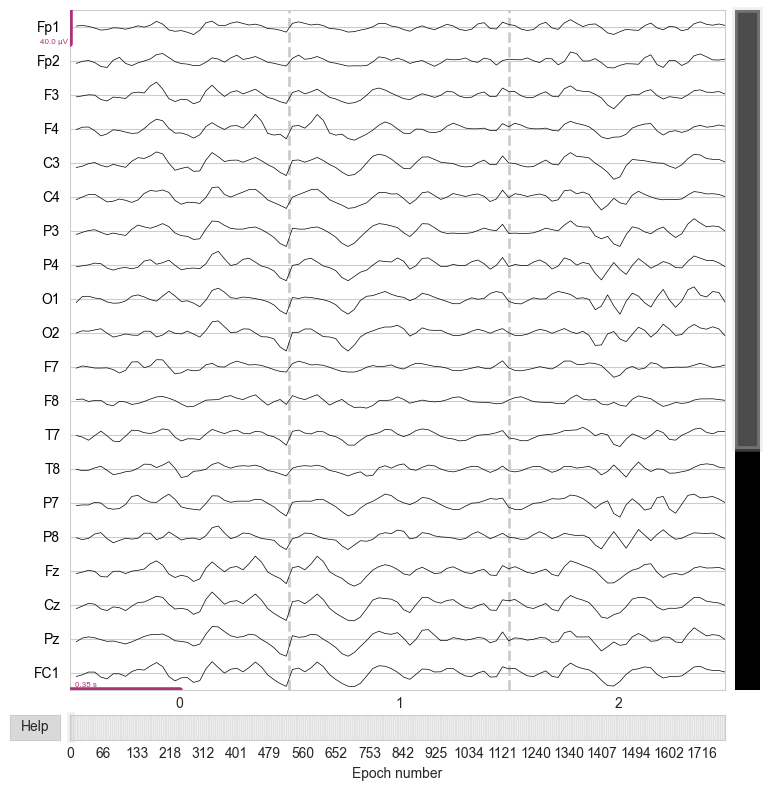

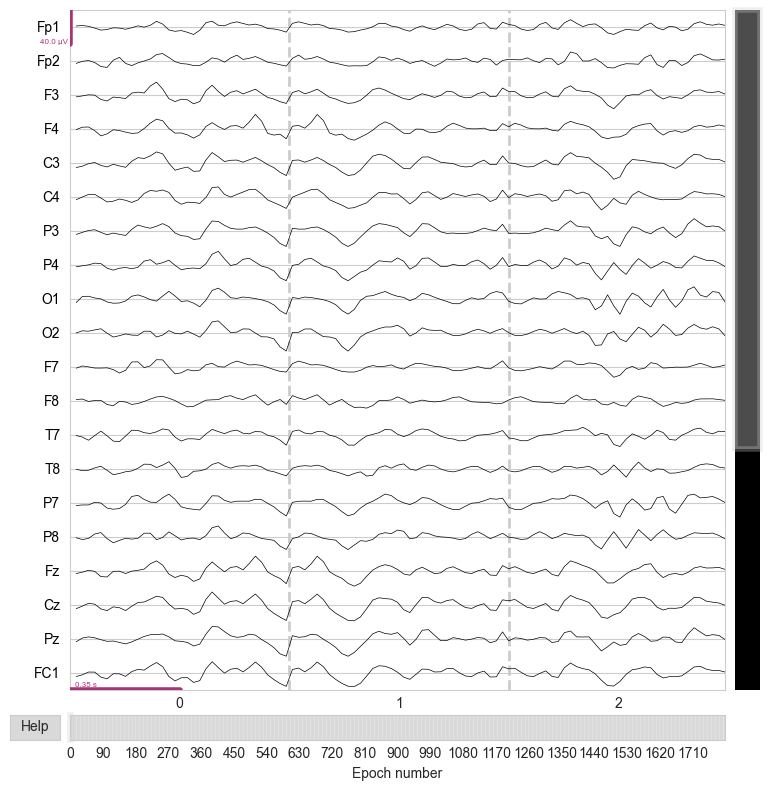

In [14]:
# Impacted performance should be higher for first subject
new_data['erp_subject_1']['slow'].plot(n_epochs=3)
all_data['erp_subject_1']['slow'].plot(n_epochs=3)
print()

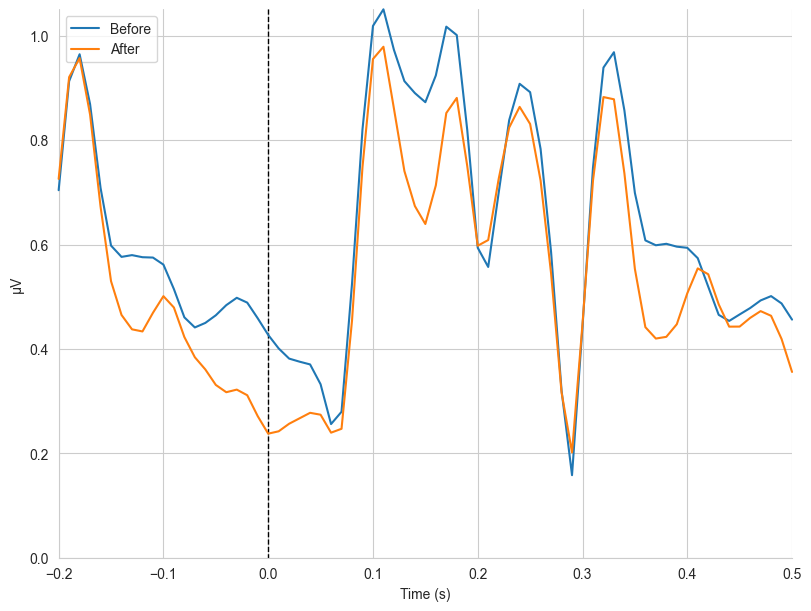

[<Figure size 800x600 with 1 Axes>]

In [10]:
ev_before = all_data['erp_subject_1']['slow'].average()
ev_after  = new_data['erp_subject_1']['slow'].average()
mne.viz.plot_compare_evokeds({'Before': ev_before, 'After': ev_after})

After applying min–max epoch rejection, the overall ERP amplitude decreased slightly but became smoother and less noisy.This indicates that high-amplitude artifacts were removed and SNR was most probably increased. The cleaner waveform is more representative of the true signal.

## Exercise 3: Basic ERP plots

Event-related potentials are typically computed by averaging all epochs in the dataset that belong to the same condition. As a basic analysis, we visualize the ERPs over time, with time after stimulus on the x-axis. Additionally, we define certain time points at which we want to plot the signal topography over the whole scalp. 

**Note**: we are only averaging ERPs that belong to a specific condition (fast or slow), and do so for each participant separately (1, 2, and 3). In the next exercise you will look at target versus non-target epochs. 

1. Explore the scalp topography at other time points. At which time points and which locations can you see peaks in the averaged signal (i.e., ERPs)?

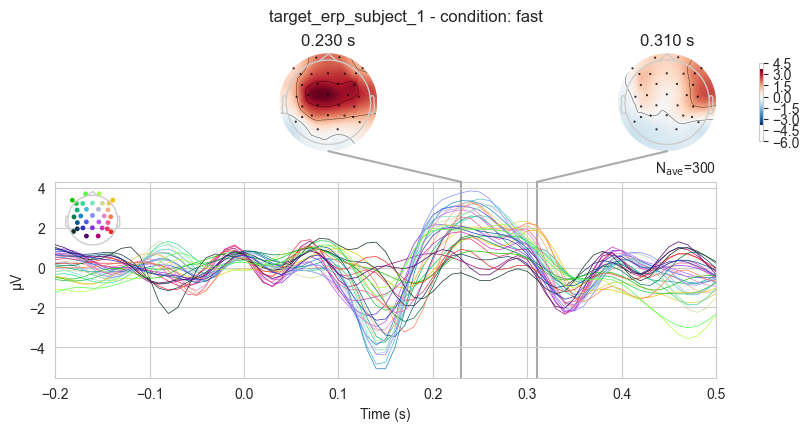

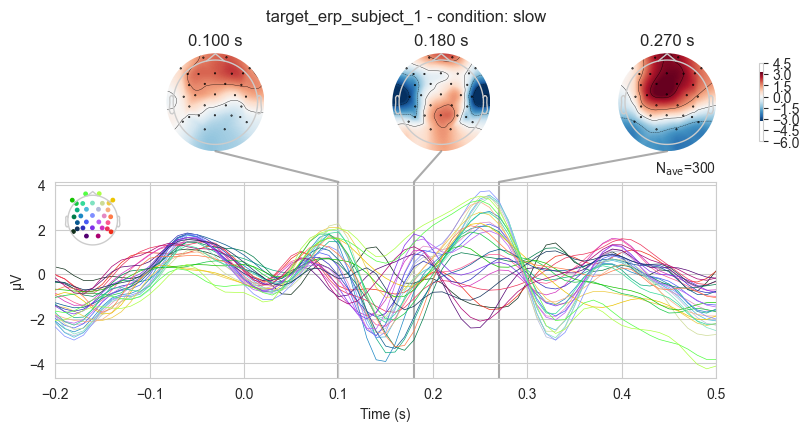

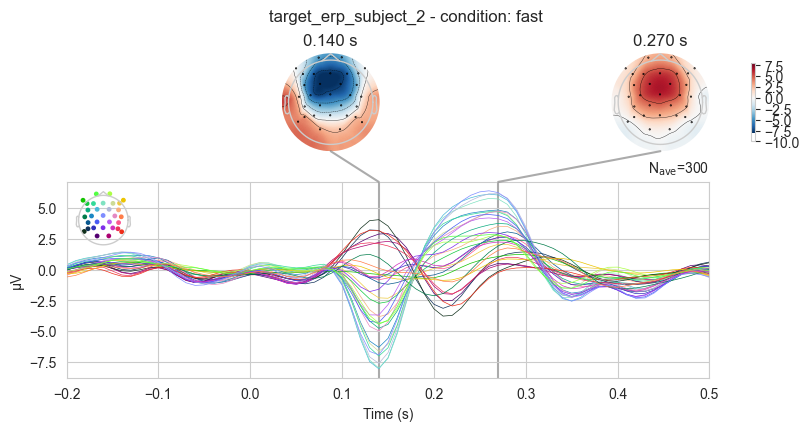

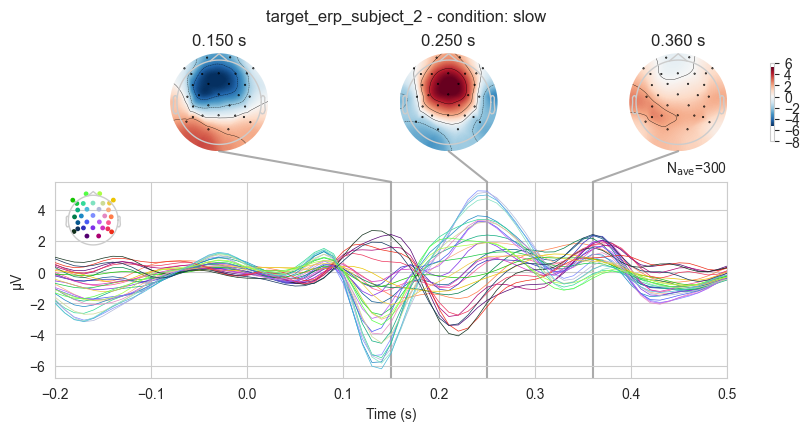

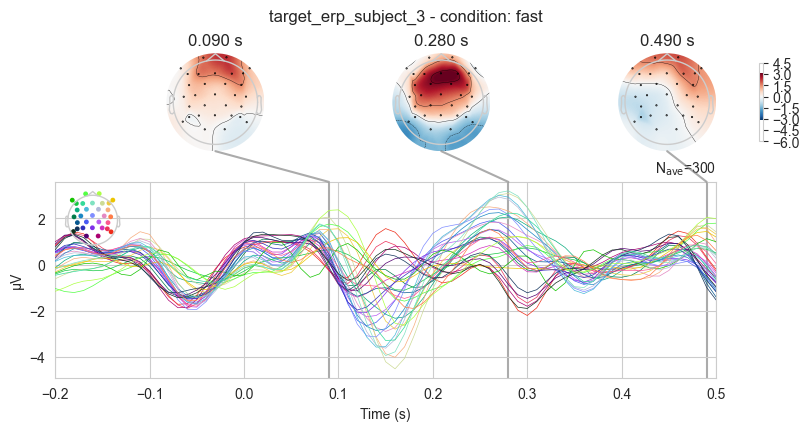

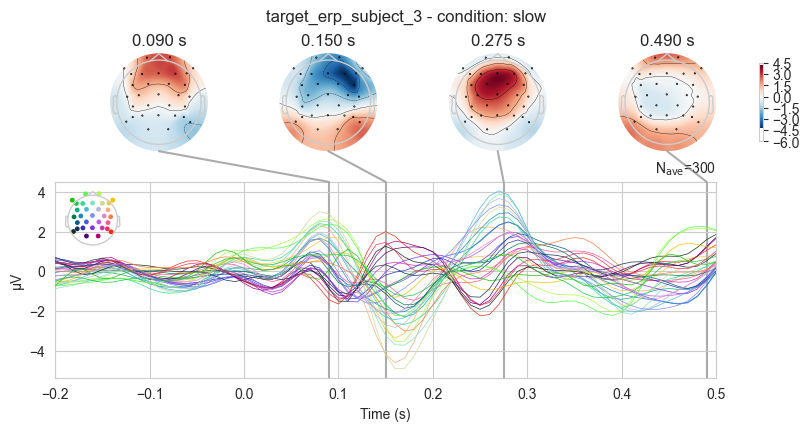

In [15]:
scalp_times = (0.0, 0.1, 0.3)
# Threshold of what is considered a peak is 2.0 μV since the oscillatory
# waveform have that average wavelength
peak_times = [
            (0.23, 0.31), 
            (0.1, 0.18, 0.27),
            (0.14, 0.27),
            (0.15, 0.25, 0.36),
            (0.09, 0.28, 0.49),
            (0.09, 0.15, 0.275, 0.49)]
idx = 0
for session in session_list:
    for condition in condition_list:
        epo = all_data[session][condition]
        
        # Compute ERP
        t_evoked = epo['Target'].average()
        
        
        # Plot ERP
        t_evoked.plot_joint(title=f'target_{session} - condition: {condition}', times=peak_times[idx]);
        idx += 1


The location can be found by the scalp/EEG cap schematic of the time points above the waveform. Peak are considered only the positivities but most time they are preceded by a negativity.

Top (upwards)	    Fp1, Fp2, F3, F4, Fz	    Frontal

Middle	            C3, Cz, C4	                Central

Lower/Lowest    	P3, P4, Pz, O1, O2	        Parietal / Occipital

Left / Right edges	F7/F8, T7/T8, P7/P8	        Temporal

## (Optional) Exercise 4: Classification in the spatial domain for different time intervals

As a first step, we want to classify the target vs. non-target signals. Remember that our data has the following dimensionality: $X_i \in \mathbb{R}^{N_c \times N_t}$ with $X_i$ being the ith epoch, $N_c$ being the number of channels and $N_t$ being the number of time samples available in the $i$-th epoch. In the next step, we will only use spatial information for classification, i.e. choose an arbitrary time-point such as 200ms after the stimulus, and use the 31-dimensional feature vector ($N_c = 31$ in this dataset) to classify between target and non-target stimuli based on that time point only (but all channels).

Instead of arbitrarily choosing a specific time point, we evaluate the classification performance for each time point individually between -0.2 s prior to the stimulus up to 0.5 s after the stimulus. This way we can plot how good the classification works, using different times. Note that this can take a while, as many classifiers are trained and evaluated (one for each time point for each subject).

**Note:** we are using sklearn's `LDA` for classification using a shrinkage regularization technique. Additionally, we using sklearn's `cross_val_score` function to perform 5-fold cross-validation. 

1. What is the most informative time interval relative to the stimulus onset? 
1. What is, roughly, the grand average classification performance at the best performing time interval?
1. Why can you observe an AUC performance above 0.5 for some time points prior to $t=0$? If you are not familiar with the ROC-AUC metric (or AUC for short), you can find a nice introduction to it in [the scikit-learn documentation](https://scikit-learn.org/stable/modules/model_evaluation.html#roc-metrics) and a more detailed one on [wikipedia](https://en.wikipedia.org/wiki/Receiver_operating_characteristic#Area_under_the_curve). 
1. How can you check if AUC = 0.5 truly is the chance level?

In [ ]:
N_sessions = len(session_list)
N_conditions = len(condition_list)
clf_times = np.arange(-0.2, 0.51, 0.01)

fig, axes = plt.subplots(N_sessions, 1, figsize=(8,10), sharey=True, sharex=True)

for s_i, session in enumerate(session_list):
    ax = axes[s_i] if N_sessions > 1 else axes
    for c_i, condition in enumerate(condition_list):
        
        # Compute scores with cross_val_score from sklearn
        scores = np.zeros((clf_times.shape[0],))
        for t_i, clf_time in enumerate(clf_times):
            
            # Extract the data
            epo = all_data[session][condition]
            X = epo.get_data()[:,:,epo.time_as_index(clf_time)].squeeze()
            y = epo.events[:,2]
            
            # Initialize classifier
            lda = LDA(solver='lsqr', shrinkage='auto')
            
            # Evaluate classifier, save average score over folds
            scores[t_i] = cross_val_score(lda, X, y, cv=5, scoring='roc_auc').mean()
            
        # Plot scores over time
        ax.plot(clf_times, scores, label=f'Condition {condition}')
        
    ax.set_title(f'AUC scores for {session}')
    ax.set_ylabel('AUC')
    
ax.set_xlabel('Time relative to stimulus onset (s)')
ax.legend()


In [ ]:
# Answer here

## (Optional) Exercise 5: Classification in the temporal domain for different channels

Now we basically do the opposite: We train one classifier per channel (thus omitting spatial information), but provide it with information from multiple time points of this channel. Thus our feature vector would be $N_t$-dimensional. As neighboring time samples probably contain very similar information, and as we want to save some computing time, we additionally use a common feature preprocessing step for ERP: we average the signal in certain time intervals, which are defined by `clf_ival_boundaries`. In this example we average, e.g., the samples between 0.1 and 0.17 seconds post stimulus before converting them into the feature vector. As a result, instead of having a 41-dimensional (every sample between 0.1 and 0.5 with a resolution of 0.01) feature vector, we only have 5 dimensions left (the five averaged time intervals). Doing this is well-justified, as our data is low-pass filtered at 16Hz, but of course you may be able to obtain better performance using other time intervals.

Again, the analysis will be repeated over the spatial dimension. Overall, this analysis allows us to see, how good classification is on each channel individually.

**Note:** as we use multiple time intervals, we 'smear' information across all time intervals. This means that the spatial information could be aligned differently in the first time interval than in the last one (i.e. a channel given could be very informative in one time interval but not in the others). To see spatial classification performance in each time interval, you would need to also iterate over the intervals of `clf_ival_boundaries`.

You may observe substantial differences between channels regarding their information content for our binary target vs. non-target problem. In addition, you should also observe, that the performance varies strongly between subjects.

1. What is the most informative channel? 
1. What is, roughly, the grand average classification performance at the best performing channel?


In [ ]:
def get_jumping_means(epo, boundaries):
    shape_orig = epo.get_data().shape
    X = np.zeros((shape_orig[0], shape_orig[1], len(boundaries)-1))
    for i in range(len(boundaries)-1):
        idx = epo.time_as_index((boundaries[i], boundaries[i+1]))
        idx_range = list(range(idx[0], idx[1]))
        X[:,:,i] = epo.get_data()[:,:,idx_range].mean(axis=2)
    return X


clf_ival_boundaries = np.array([0.1, 0.17, 0.23, 0.3, 0.41, 0.5])

fig, axes = plt.subplots(N_sessions, N_conditions, figsize=(8,8))

for s_i, session in enumerate(session_list):
    for c_i, condition in enumerate(condition_list):
        ax = axes[c_i] if N_sessions == 1 else axes[s_i, c_i]
        
        # Compute scores with cross_val_score from sklearn
        scores = np.zeros((len(epo.ch_names),))
        for ch_i, ch_name in enumerate(epo.ch_names):
            
            # Extract the data
            epo = all_data[session][condition]
            X = get_jumping_means(epo.copy().pick([ch_name]), clf_ival_boundaries).squeeze()
            y = epo.events[:,2]
            
            # Initialize classifier
            lda = LDA(solver='lsqr', shrinkage='auto')
            
            # Evaluate classifier, save average score over folds
            scores[ch_i] = cross_val_score(lda, X, y, cv=5, scoring='roc_auc').mean()
            
        # Plot scores over space
        im, cn = mne.viz.plot_topomap(scores, epo.info, axes=ax, cmap='RdBu_r', show=False, vlim=(0,1)) 
        ax.set_title(f'AUC for {session}, condition {condition}')
        plt.colorbar(im, ax=ax)
        

In [ ]:
# Answer here

## Exercise 6: Classification in the spatio-temporal domain

The above two analysis (over space and over time) provide great inside into where the decodable information is. In practice, we usually do not split our features into spatial and temporal domains, but instead integrate information from both domains into one feature vector. This allows us to use all collected information in one go. Still, classifiers like LDA expect a feature vector, not a spatio-temporal data matrix. To arrive at one feature vector, we simply concatenate the five temporal features for every channel (note, LDA does not care about the order of the features). 

1. What is the grand average performance (across sessions) in this case? Is it higher than the previous two analyses? 
1. While this should lead to increased performance, it comes with the drawback that we cannot create the previous nice plots anymore. Can you come up with a way to inspect the results to answer, roughly, where the decodable information is located (both in space as well as in time)?

   Explore the following:
1. How does performance change, if the LDA uses no regularization? 
1. Does regularization make a difference, if you train your LDA model on much smaller data sets, e.g. on data of 2 trials only (corresponding to 30 targets and 150 non-targets)? 
1. Can you plot the effect of shrinkage regularization as a function of data set size?

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(5,3))

for s_i, session in enumerate(session_list):
    scores = np.zeros((N_conditions,))
    for c_i, condition in enumerate(condition_list):
        
        # Extract the data
        epo = all_data[session][condition]
        X = get_jumping_means(epo, clf_ival_boundaries).squeeze().reshape((-1, 155))  # flattens
        y = epo.events[:,2]
        
        # Initialize classifier
        lda = LDA(solver='lsqr', shrinkage='auto')
        
        # Evaluate classifier, save average score over folds
        scores[c_i] = cross_val_score(lda, X, y, cv=5, scoring='roc_auc').mean()
    
    # Plot scores as scatter
    ax.scatter(session, scores[0], label='Condition fast', color='b', marker='x')
    ax.scatter(session, scores[1], label='Condition slow', color='r', marker='x')
    if s_i == 0:
        plt.legend()
plt.title('AUC for spatio-temporal classification')


In [ ]:
# Answer here

## (optional) Exercise 7: Permutation testing
You might observe that in the previous analyses, sometimes the classifier is performing around chance level (50%). Despite that (under an engineering perspective) one may conclude the classifier did a poor job, one (under a neuroscientific perspective) can be very interested in whether it is *just* above chance level, as it means that there is just some decodable information at that location (being in time or space). A common and very flexible way of significance testing in such scenario is to perform **permutation testing**. 

From Wikipedia: "A permutation test (also called a randomization test, re-randomization test, or an exact test) is a type of statistical significance test in which the distribution of the test statistic under the null hypothesis is obtained by calculating all possible values of the test statistic under all possible rearrangements of the observed data points."

To put it into context. In our dataset we are interested in whether we can decode target versus non-target from the data. For this, we got data samples that are tuples containing $(X_i, y_i)$, the data and the target label. Now, within a permutation test, we randomize (permute) the particular structure we are originally interested in, in this case the pairing of $X_i$ with $y_i$. Concretely, here we can basically randomize this by shuffling the vector $y=[y_1, y_2, ..., y_N]$ to e.g. $y_{permuted}=[y_3, y_N, ..., y_2]$. We perform the same analysis on this shuffled dataset, and save its result. If we do this many times (in the order of 1000 times), we obtain a so-called **permutation distribution** of the test statistic (e.g. classification performance). We can then look-up where in this distribution we can find our original test statistic (i.e., the one without shuffling the labels). We say that the original test statistic is significantly above chance if no more than 5% of the samples in the permutation distribution are higher than the original test statistic ($\alpha=.05$).

1. Implement this permutation test for the decoding over time at time interval -50ms. **Hint:** it requires you to write a loop over the analysis that is provided already, and to shuffle the labeling in `y` e.g. with `np.random.permutation()`;
1. Plot the permutation distribution. What does it look like, can you explain its shape?
1. Is the decoding at this time interval significant?

In [ ]:
# Answer here

## Exercise 0: Who did what?
Please provide a short description on who contributed what to your submission.

> Answer here